# Notebook 05 — Multi-Class Anomaly Detection & Baseline Comparison

**Paper**: *An Explainable, Data-Efficient Framework for Multi-Class Fault Diagnosis and Carbon-Loss Quantification in Early-Stage Solar PV Monitoring*

This notebook supports:
- **Section IV-C** — Multi-class anomaly taxonomy (rule + ML hybrid)
- **Section IV-D** — Baseline comparison (IF, OC-SVM, LOF)
- **Section V** — Experimental setup (Cohen's Kappa, synthetic fault injection)
- **Section VI** — Results & Discussion (baseline comparison)

---

In [1]:
# === Setup ===
import sys, os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

from scripts.paper.anomaly_taxonomy import apply_taxonomy, get_taxonomy_summary
from scripts.paper.evaluation import (
    compute_cohens_kappa, compute_classification_metrics,
    create_agreement_heatmap, create_confusion_matrix_plot
)
from scripts.paper.fault_injection import create_injected_dataset
from scripts.paper.plot_utils import (
    set_paper_style, save_fig, COLORS, ANOMALY_COLORS, METHOD_COLORS,
    dual_column_figsize, single_column_figsize, format_thousands
)

set_paper_style()
print('Setup complete.')

Setup complete.


## 1. Load Paper Dataset

We load the dataset produced by Notebook 04 which includes `EXPECTED_AC_POWER` and all features.

In [2]:
# Load paper dataset from Notebook 04
df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'paper_dataset.csv'))
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df['DATE'] = pd.to_datetime(df['DATE'])

print(f'Dataset shape: {df.shape}')
print(f'Daytime records: {df["IS_DAY"].sum():,}')

Dataset shape: (136476, 33)
Daytime records: 77,098


## 2. Multi-Class Anomaly Taxonomy (Rule-Based)

Our taxonomy classifies each daytime record into one of **6 classes**, each mapping to a specific **O&M action**. This is a key contribution: unlike binary anomaly detection, our multi-class approach provides **actionable** fault diagnosis.

In [3]:
# Apply taxonomy
df = apply_taxonomy(df)

# === Table II: Anomaly Class Distribution ===
summary = get_taxonomy_summary(df)
print('=== Table II: Anomaly Class Distribution ===')
print(summary.to_string(index=False))
print(f'\nTotal anomalous records: {(df["ANOMALY_BINARY"] == 1).sum():,}')
print(f'Anomaly rate: {(df["ANOMALY_BINARY"] == 1).mean()*100:.2f}%')

=== Table II: Anomaly Class Distribution ===
       Class  Count  Percentage                                                                   O&M Action
      NORMAL 132282       96.93                                            Performance within expected range
  TOTAL_LOSS   3821        2.80 AC output is zero despite sufficient irradiation → dispatch crew immediately
PARTIAL_LOSS    373        0.27 AC output < 50% of peer average under adequate sunlight → inspect within 24h

Total anomalous records: 4,194
Anomaly rate: 3.07%


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_06_anomaly_class_distribution.png


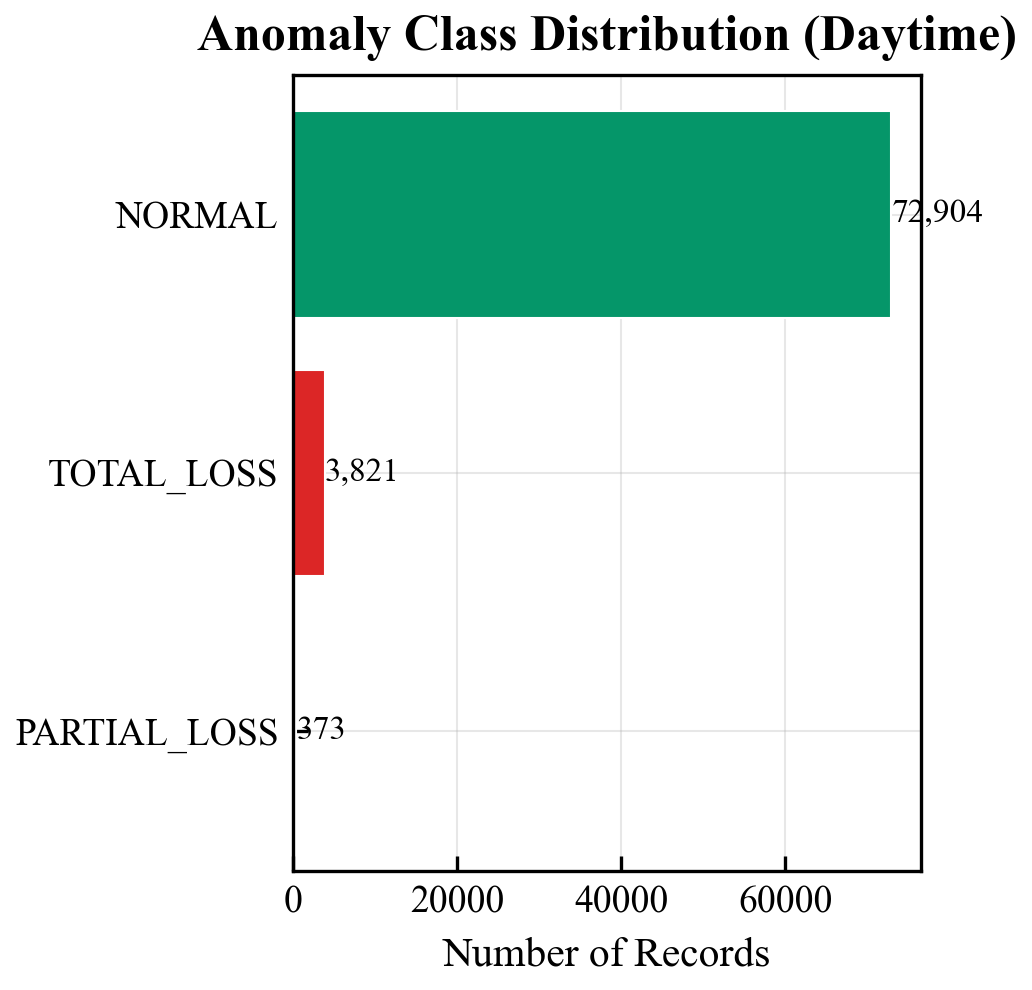

In [4]:
# === Fig 6: Anomaly Class Distribution ===

# Only daytime
day_classes = df[df['IS_DAY'] == True]['ANOMALY_CLASS'].value_counts()

fig, ax = plt.subplots(figsize=single_column_figsize(3.5))
colors = [ANOMALY_COLORS.get(cls, '#999999') for cls in day_classes.index]
bars = ax.barh(day_classes.index, day_classes.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of Records')
ax.set_title('Anomaly Class Distribution (Daytime)', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for bar, val in zip(bars, day_classes.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontsize=8)

plt.tight_layout()
save_fig(fig, 'fig_06_anomaly_class_distribution')
plt.show()

## 3. ML Baseline Comparison

We compare three unsupervised anomaly detection methods:
1. **Isolation Forest** — tree-based isolation of anomalies
2. **One-Class SVM** — boundary-based novelty detection
3. **Local Outlier Factor (LOF)** — density-based outlier detection

All methods are trained on daytime data with standardized features.

> **Note on ground truth**: In the absence of verified fault labels, we report inter-method agreement using Cohen's Kappa (Landis & Koch, 1977) rather than claiming true Precision/Recall.

In [5]:
# === Prepare features for anomaly detection ===

AD_FEATURES = [
    'AC_POWER', 'DC_POWER_CORRECTED', 'EFFICIENCY_CORRECTED',
    'IRRADIATION', 'MODULE_TEMPERATURE', 'HOUR_SIN', 'HOUR_COS',
    'POWER_GAP_PERCENT'
]

# Daytime only, drop NaN rows
day_df = df[df['IS_DAY'] == True].copy()
day_clean = day_df.dropna(subset=AD_FEATURES).copy()

print(f'Daytime records for AD: {len(day_clean):,}')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(day_clean[AD_FEATURES])

print(f'Feature matrix shape: {X_scaled.shape}')

Daytime records for AD: 77,098


Feature matrix shape: (77098, 8)


In [6]:
# === Train 3 baselines ===

# 1. Isolation Forest
iforest = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)
if_labels = iforest.fit_predict(X_scaled)
day_clean['IF_ANOMALY'] = (if_labels == -1).astype(int)

# 2. One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
ocsvm_labels = ocsvm.fit_predict(X_scaled)
day_clean['OCSVM_ANOMALY'] = (ocsvm_labels == -1).astype(int)

# 3. LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_labels = lof.fit_predict(X_scaled)
day_clean['LOF_ANOMALY'] = (lof_labels == -1).astype(int)



## 4. Evaluation: Cohen's Kappa (Inter-Method Agreement)

> "In the absence of verified ground truth, we report inter-method agreement using Cohen's Kappa rather than claiming true Precision/Recall. This is methodologically honest and avoids the point-adjusted F1 critique common in the time-series anomaly detection literature."

In [7]:
# === Table III: Cohen's Kappa Matrix ===

methods = {
    'Rule-Based': day_clean['ANOMALY_BINARY'].values,
    'Isolation Forest': day_clean['IF_ANOMALY'].values,
    'One-Class SVM': day_clean['OCSVM_ANOMALY'].values,
    'LOF': day_clean['LOF_ANOMALY'].values,
}

kappa_results = []
method_names = list(methods.keys())

for i in range(len(method_names)):
    for j in range(i+1, len(method_names)):
        result = compute_cohens_kappa(
            methods[method_names[i]],
            methods[method_names[j]],
            method_names[i],
            method_names[j],
        )
        kappa_results.append(result)

kappa_df = pd.DataFrame(kappa_results)
print('=== Table III: Cohen\'s Kappa (Inter-Method Agreement) ===')
print(kappa_df[['Method_1', 'Method_2', 'Kappa', 'Interpretation', 'Agreement_Rate']].to_string(index=False))

=== Table III: Cohen's Kappa (Inter-Method Agreement) ===
        Method_1         Method_2  Kappa     Interpretation  Agreement_Rate
      Rule-Based Isolation Forest 0.2964     Fair agreement          0.8062
      Rule-Based    One-Class SVM 0.2589     Fair agreement          0.8938
      Rule-Based              LOF 0.0520   Slight agreement          0.9205
Isolation Forest    One-Class SVM 0.4047 Moderate agreement          0.8224
Isolation Forest              LOF 0.0591   Slight agreement          0.7510
   One-Class SVM              LOF 0.0861   Slight agreement          0.8846


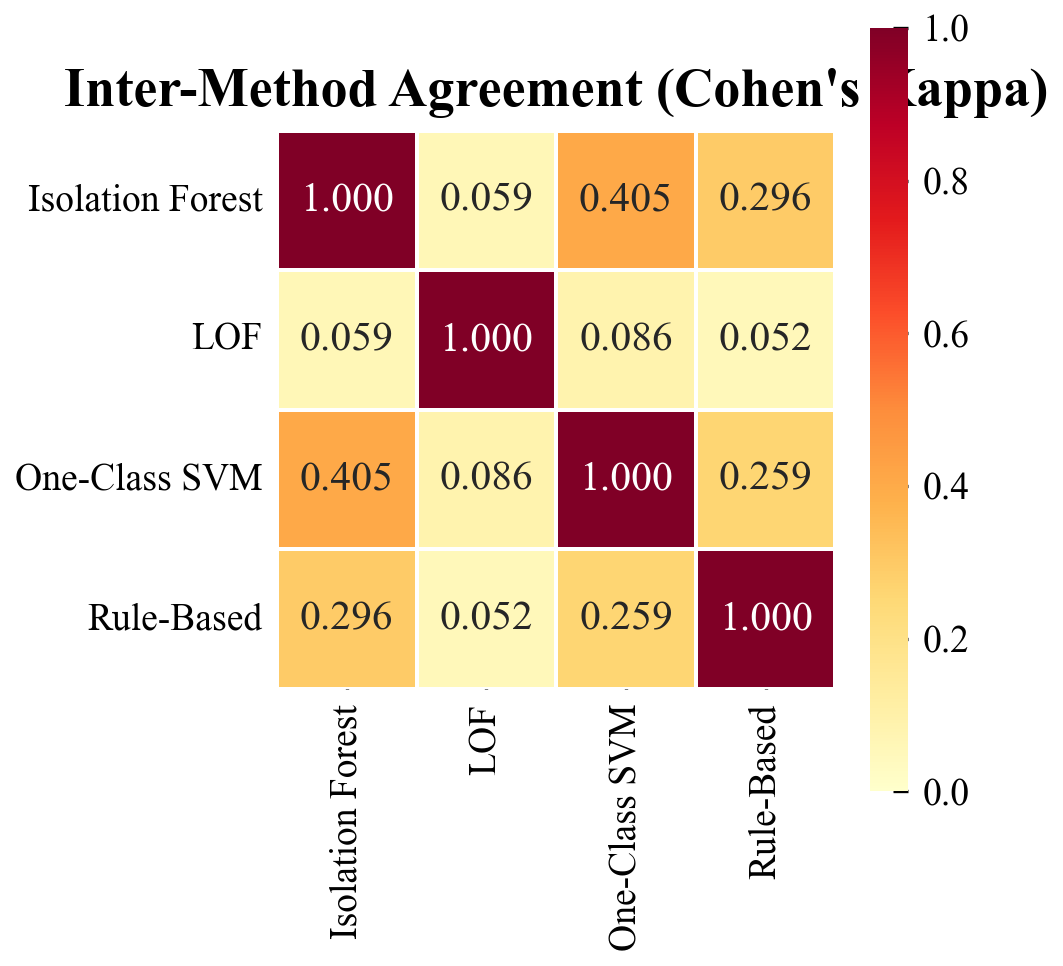

In [8]:
# === Fig 7: Agreement Heatmap ===

fig = create_agreement_heatmap(
    kappa_results,
    save_path=os.path.join(PROJECT_ROOT, 'reports', 'figures', 'paper', 'fig_07_agreement_heatmap.png'),
    figsize=single_column_figsize(3.5),
)
plt.show()

In [9]:
# === Anomaly count comparison by method ===

count_summary = pd.DataFrame({
    'Method': ['Rule-Based', 'Isolation Forest', 'One-Class SVM', 'LOF'],
    'Anomaly Count': [
        day_clean['ANOMALY_BINARY'].sum(),
        day_clean['IF_ANOMALY'].sum(),
        day_clean['OCSVM_ANOMALY'].sum(),
        day_clean['LOF_ANOMALY'].sum(),
    ],
    'Anomaly Rate (%)': [
        round(day_clean['ANOMALY_BINARY'].mean() * 100, 2),
        round(day_clean['IF_ANOMALY'].mean() * 100, 2),
        round(day_clean['OCSVM_ANOMALY'].mean() * 100, 2),
        round(day_clean['LOF_ANOMALY'].mean() * 100, 2),
    ],
})
print('\n=== Anomaly Count Comparison ===')
print(count_summary.to_string(index=False))


=== Anomaly Count Comparison ===
          Method  Anomaly Count  Anomaly Rate (%)
      Rule-Based           4194              5.44
Isolation Forest          19118             24.80
   One-Class SVM           7695              9.98
             LOF           2551              3.31


## 5. Synthetic Fault Injection (Optional — Ground Truth Evaluation)

To obtain **true P/R/F1**, we inject controlled faults into a subset of clean data. This provides verified labels for proper evaluation, addressing the fundamental limitation of unsupervised anomaly detection on this dataset.

In [10]:
# === Synthetic fault injection ===

# Use only "normal" daytime records as the clean base
clean_base = day_clean[day_clean['ANOMALY_CLASS'] == 'NORMAL'].copy()
print(f'Clean base records: {len(clean_base):,}')

# Select 3 inverters per plant for injection
df_injected, gt_labels = create_injected_dataset(clean_base, seed=42)

print(f'Injected faults: {gt_labels.sum():,} records')
print(f'Injection rate: {gt_labels.mean()*100:.2f}%')

Clean base records: 72,904
Injected faults: 100 records
Injection rate: 0.14%


In [11]:
# === Re-run baselines on injected data ===

# Re-compute features that might change (PEER_AVG, etc. are from original)
X_inj_scaled = scaler.transform(df_injected[AD_FEATURES].fillna(0))

# Isolation Forest
if_inj = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)
if_inj_labels = (if_inj.fit_predict(X_inj_scaled) == -1).astype(int)

# One-Class SVM
ocsvm_inj = OneClassSVM(kernel='rbf', nu=0.1, gamma='scale')
ocsvm_inj_labels = (ocsvm_inj.fit_predict(X_inj_scaled) == -1).astype(int)

# LOF
lof_inj = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_inj_labels = (lof_inj.fit_predict(X_inj_scaled) == -1).astype(int)

# Rule-based on injected data
from scripts.paper.anomaly_taxonomy import apply_taxonomy
df_inj_tax = apply_taxonomy(df_injected)
rule_inj_labels = df_inj_tax['ANOMALY_BINARY'].values

print('Baselines re-run on injected data.')

Baselines re-run on injected data.


In [12]:
# === Table IV: P/R/F1 on Synthetic Faults ===

gt = gt_labels.astype(int).values

synth_results = []
for name, preds in [
    ('Rule-Based', rule_inj_labels),
    ('Isolation Forest', if_inj_labels),
    ('One-Class SVM', ocsvm_inj_labels),
    ('LOF', lof_inj_labels),
]:
    metrics = compute_classification_metrics(gt, preds, name)
    synth_results.append(metrics)

synth_df = pd.DataFrame(synth_results)
print('=== Table IV: Classification Metrics on Synthetic Faults ===')
print(synth_df.to_string(index=False))

# Save
synth_df.to_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'synthetic_fault_evaluation.csv'), index=False)

=== Table IV: Classification Metrics on Synthetic Faults ===
          Method  Precision  Recall     F1  Kappa
      Rule-Based     1.0000    0.58 0.7342 0.7339
Isolation Forest     0.0065    1.00 0.0129 0.0102
   One-Class SVM     0.0109    0.79 0.0214 0.0188
             LOF     0.0258    0.59 0.0495 0.0470


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_08_baseline_comparison.png


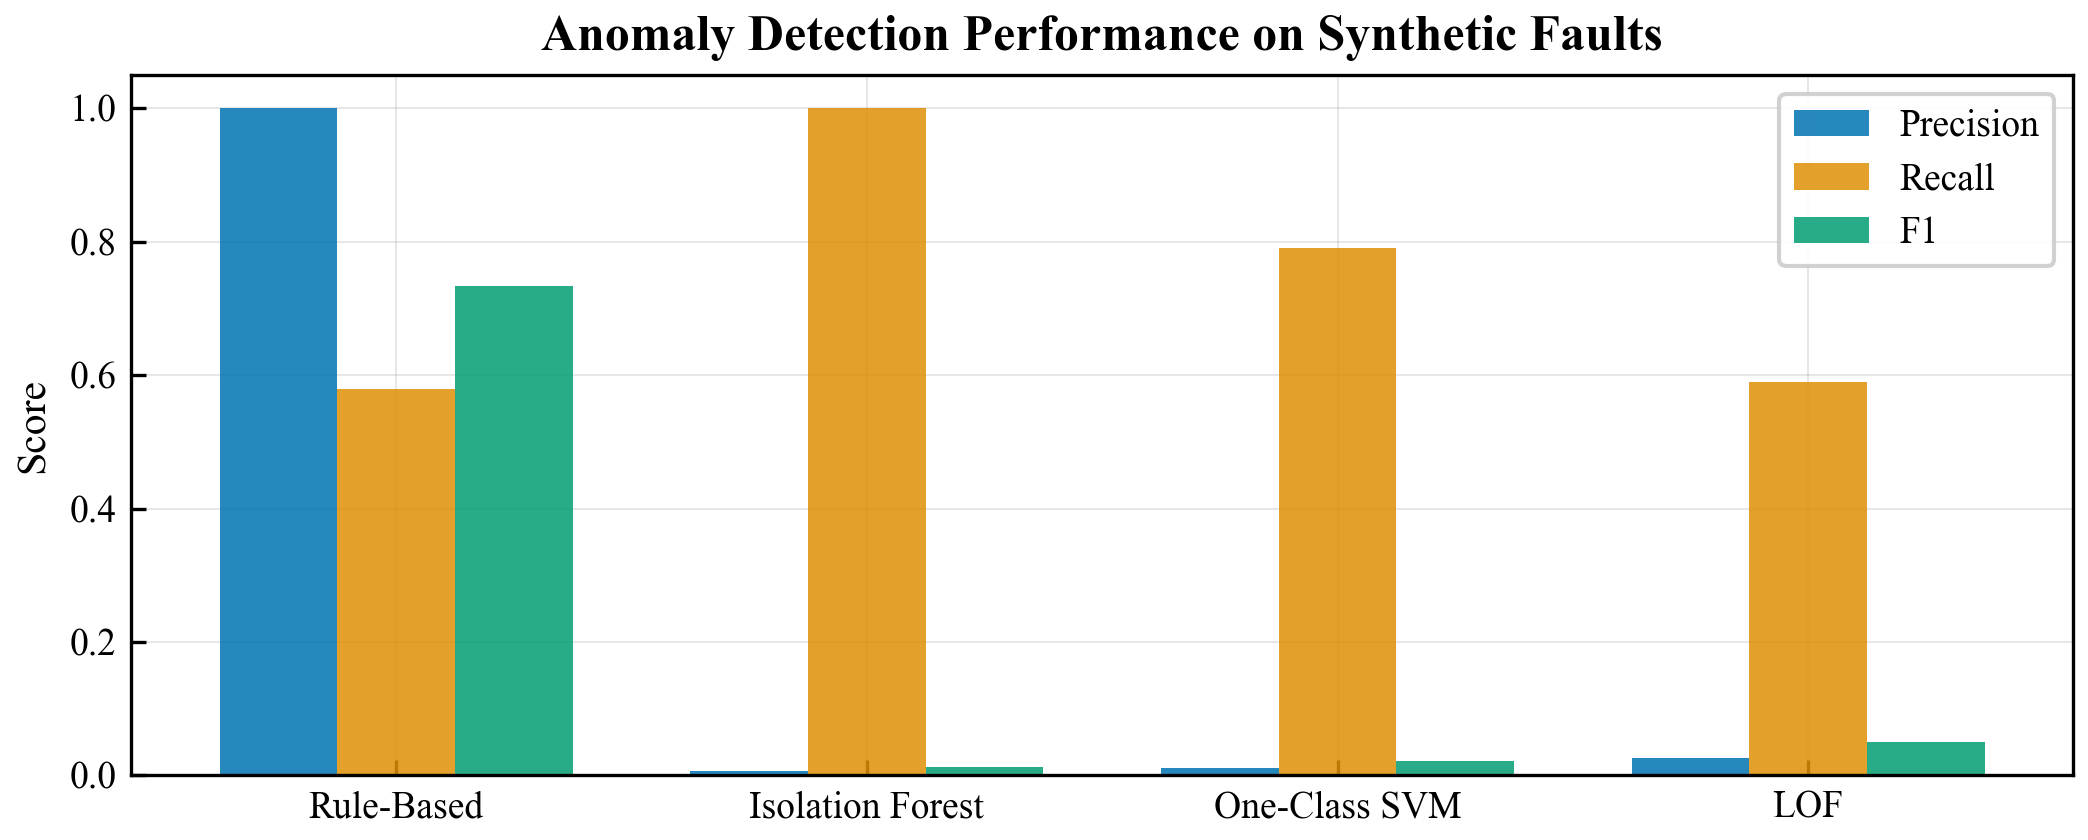

In [13]:
# === Fig 8: Baseline Comparison Bar Chart ===

fig, ax = plt.subplots(figsize=dual_column_figsize(3.0))

x = np.arange(len(synth_df))
width = 0.25

for i, metric in enumerate(['Precision', 'Recall', 'F1']):
    ax.bar(x + i * width, synth_df[metric], width, label=metric, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(synth_df['Method'], fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Anomaly Detection Performance on Synthetic Faults', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
save_fig(fig, 'fig_08_baseline_comparison')
plt.show()

In [14]:
# === Save all anomaly results ===

output_cols = [
    'DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AC_POWER', 'DC_POWER_CORRECTED',
    'IRRADIATION', 'MODULE_TEMPERATURE', 'EXPECTED_AC_POWER',
    'ANOMALY_CLASS', 'ANOMALY_BINARY', 'IF_ANOMALY', 'OCSVM_ANOMALY', 'LOF_ANOMALY',
    'POWER_LOSS_KW', 'ENERGY_LOSS_KWH', 'CO2_LOSS_KG',
]

# Only save columns that exist
output_cols_exist = [c for c in output_cols if c in day_clean.columns]

output_path = os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'anomaly_baseline_results.csv')
day_clean[output_cols_exist].to_csv(output_path, index=False)
print(f'Anomaly baseline results saved: {output_path}')

Anomaly baseline results saved: D:\Aptech\Du_an\data\processed\paper\anomaly_baseline_results.csv


## 6. Summary

### Key outputs from this notebook:
- **Table II**: Anomaly class distribution (multi-class taxonomy)
- **Table III**: Cohen's Kappa inter-method agreement matrix
- **Table IV**: P/R/F1 on synthetic faults (with ground truth)
- **Fig 6**: Anomaly class distribution bar chart
- **Fig 7**: Cohen's Kappa agreement heatmap
- **Fig 8**: Baseline comparison (P/R/F1) bar chart
- **anomaly_baseline_results.csv**: Full results for Notebook 06 case studies